# P1 — 3 × 3 equity-curve grid

Headline figure for the results section:  for each of the 3 pairs × 3 months
(AUDUSD/NZDUSD, GBPUSD/EURUSD, EURNOK/EURSEK  ×  Aug-24, Sep-24, Aug-25)
show the cumulative-PnL curves of `BuyHold`, `Baseline`, `AR` and `MS_AR` on
shared axes.

Why this plot:  it makes the 'BuyHold often wins' story visible in one shot and
shows where AR's hard-kill actually buys protection (GBPEUR Aug-24, NOKSEK Aug-25).

Runs all 9 backtests sequentially (≈5–10 min total).  Output is one PDF:
`code/plots/eda/monthly_equity_grid.pdf`.

In [1]:
import os, sys
if os.path.exists('/content'):
    os.system('curl -sL https://raw.githubusercontent.com/egil10/stk-mat2011/main/code/scripts/colab.py -o /content/colab.py')
    sys.path.insert(0, '/content')
    from colab import setup; setup('code/visualisations')
else:
    sys.path.insert(0, '../scripts')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD           : /content/stk-mat2011/code/visualisations
Scripts path  : /content/stk-mat2011/code/scripts
Data symlink  : /content/stk-mat2011/code/data/processed -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet files : 916


In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt

from month    import MONTH
from plotting import apply_econ_style, ECON, save_figure_pdf
apply_econ_style()

PAIRS  = [('AUDUSD', 'NZDUSD'), ('GBPUSD', 'EURUSD'), ('EURNOK', 'EURSEK')]
MONTHS = ['202408', '202409', '202508']
STRATS = ['BuyHold', 'Baseline', 'AR', 'MS_AR']

In [3]:
runs = {}                                              # {pair_key: {month: results}}
for a, b in PAIRS:
    print(f'\n── running {a}/{b} ──')
    mm = MONTH(a, b, save_plots=False)
    mm.run_months(MONTHS)
    runs[f'{a}_{b}'] = {m: mm.runs[m][0] for m in MONTHS}


── running AUDUSD/NZDUSD ──
Engine: train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
[2024-08-23] skipped: Steady-state probabilities could not be constructed.
202408  bars=2,787  days=22  | Sharpe  B= -6.36  AR= -7.49  MS= -5.14
202409  bars=2,175  days=21  | Sharpe  B=+22.16  AR= +5.65  MS=+20.10
202508  bars=1,960  days=21  | Sharpe  B=+19.68  AR=-19.40  MS= +1.64

── running GBPUSD/EURUSD ──
Engine: train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
[2024-08-19] skipped: Steady-state probabilities could not be constructed.
202408  bars=3,470  days=22  | Sharpe  B= -0.49  AR=+23.53  MS= +4.39
202409  bars=3,818  days=21  | Sharpe  B=+19.13  AR= +8.34  MS=+16.98
202508  bars=2,884  days=21  | Sharpe  B= +4.81  AR=-22.73  MS= +1.23

── running EURNOK/EURSEK ──
Engine: train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
202408  bars=9,088  days=22  | Sharpe  B=-43.87  AR=

Saved plot PDF: ../plots/eda/monthly_equity_grid.pdf


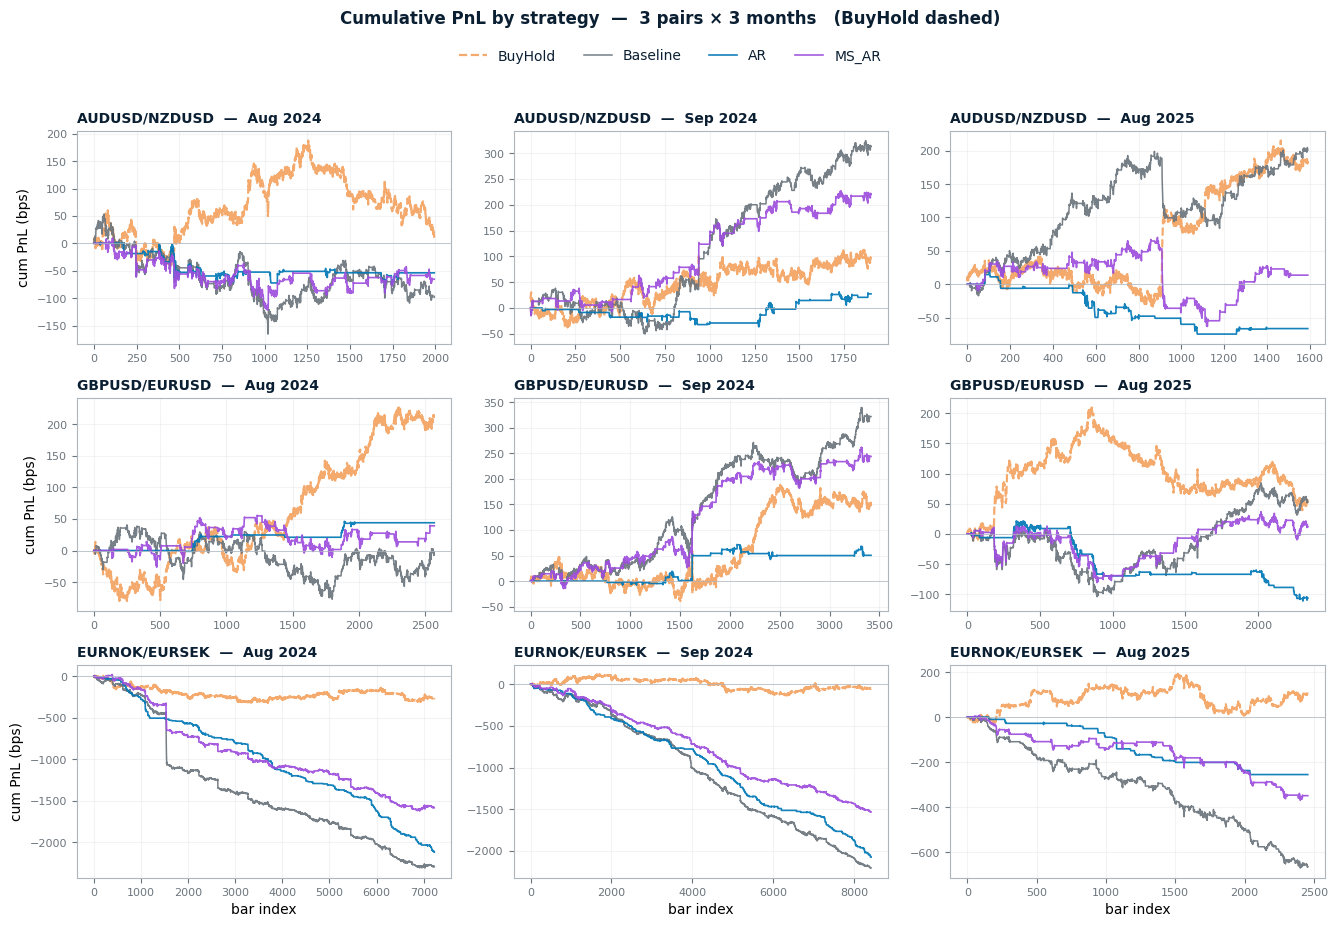

In [4]:
PRETTY = {'202408': 'Aug 2024', '202409': 'Sep 2024', '202508': 'Aug 2025'}
PAL    = {s: ECON[s] for s in STRATS}
LS     = {'BuyHold': '--', 'Baseline': '-', 'AR': '-', 'MS_AR': '-'}
LW     = {'BuyHold': 1.6,  'Baseline': 1.1, 'AR': 1.2, 'MS_AR': 1.2}

fig, axes = plt.subplots(3, 3, figsize=(13.5, 9), sharex=False)
for i, (a, b) in enumerate(PAIRS):
    for j, m in enumerate(MONTHS):
        ax  = axes[i, j]
        res = runs[f'{a}_{b}'][m]
        x   = np.arange(len(res))
        for s in STRATS:
            y = res[f'CumReturn_{s}'].values * 1e4
            ax.plot(x, y, color=PAL[s], ls=LS[s], lw=LW[s], alpha=0.92,
                    label=s if (i, j) == (0, 0) else None)
        ax.axhline(0, color=ECON['lt_grey'], lw=0.5)
        ax.set_title(f'{a}/{b}  —  {PRETTY[m]}', loc='left', fontsize=10, fontweight='bold')
        if j == 0: ax.set_ylabel('cum PnL (bps)')
        if i == 2: ax.set_xlabel('bar index')
        ax.tick_params(labelsize=8)

fig.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.995),
           frameon=False, fontsize=10)
fig.suptitle('Cumulative PnL by strategy  —  3 pairs × 3 months   (BuyHold dashed)',
             y=1.025, fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.965])
save_figure_pdf(fig, 'monthly_equity_grid.pdf', pdf_dir='../plots/eda', enabled=True, verbose=True)
plt.show()